Para evitar problemas de achar o caminho das funções, iniciamos com esta implementação

In [20]:
from pathlib import Path
import sys

# Caminho para a raiz do projeto
PROJECT_ROOT = Path.cwd().parent

# Adiciona ao path do Python
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\Users\Deepen\Box\Box Sync\Capacitação\Cursos Online\SENAI\Desenvolvimento IA\ProjetoFinalSena


Baixar o dataset. Se force = True, a função força baixar novamente

In [21]:
from src.phase00_data import baixar_manutencao_preditiva

df = baixar_manutencao_preditiva(force=False)

Utilizando dataset existente: D:\Users\Deepen\Box\Box Sync\Capacitação\Cursos Online\SENAI\Desenvolvimento IA\ProjetoFinalSena\data\raw\manutencao_preditiva.csv


Carregamento do dataset

In [22]:
from src.phase00_data import carregar_dataset

df = carregar_dataset()

Carregando dataset: manutencao_preditiva.csv
Dataset carregado com sucesso: 10000 linhas e 14 colunas.


Fase 1: Análise Exploratória (EDA)

In [23]:
from src.phase01_eda import (
    mostrar_dimensoes,
    mostrar_tipos,
    mostrar_estatisticas,
)

mostrar_dimensoes(df)
mostrar_tipos(df)
estatisticas = mostrar_estatisticas(df)
estatisticas


=== Dimensões do Dataset ===
Linhas : 10000
Colunas: 14
=== Tipos das Variáveis ===
udi                          int64
id_produto                  object
tipo                        object
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object
=== Estatísticas Descritivas ===


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Apresentação de histogramas e gráficos de dispesão, baseado no trabalho de Aurelien Géron (Hands-on Machine Learn with Schikit-Learn and PyTorch)

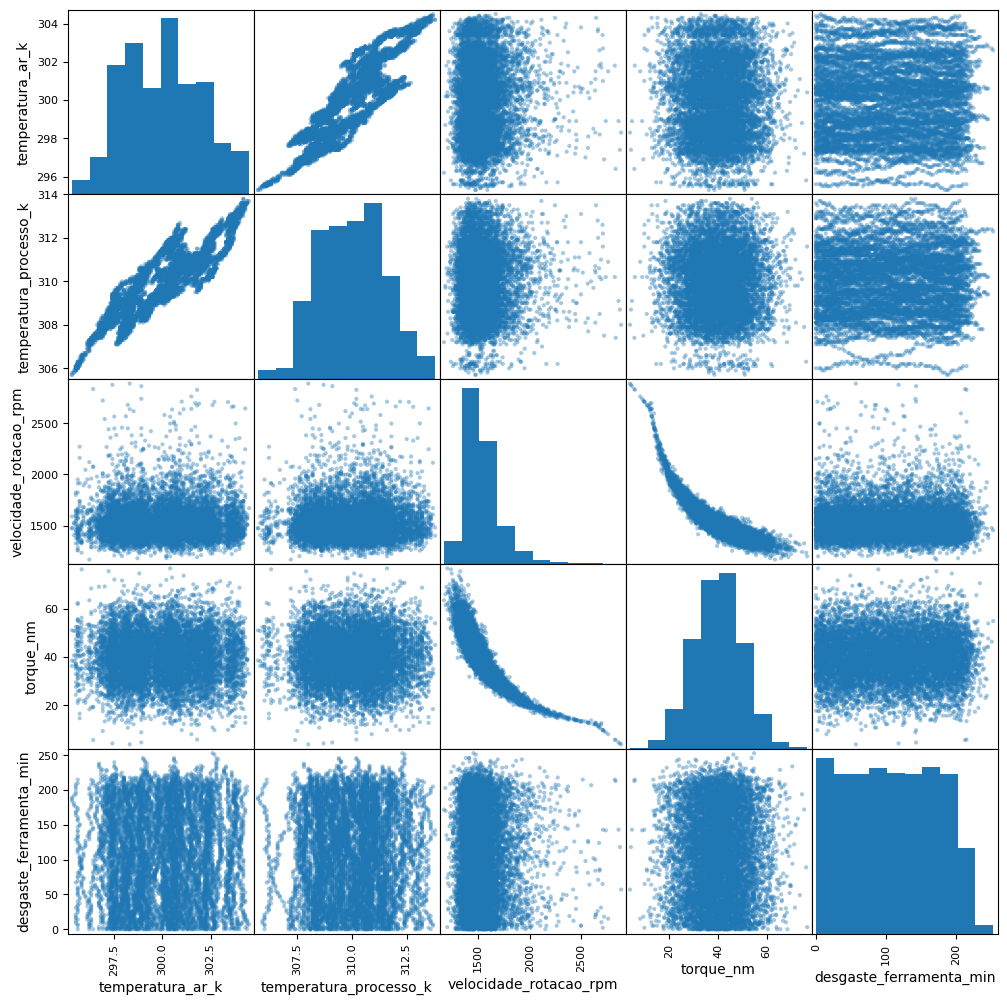

In [24]:
from src.phase01_eda import mostrar_graficos

mostrar_graficos(df)

Verificação do balanceamento da variável alvo

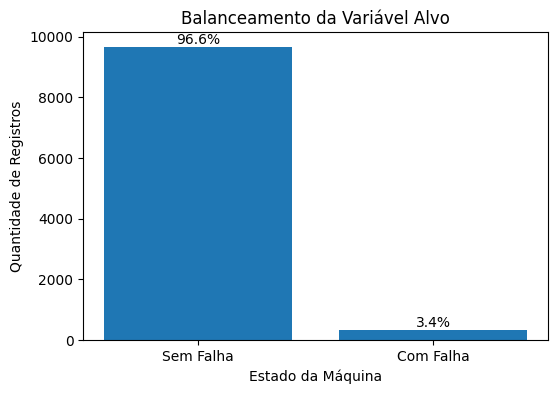

In [25]:
from src.phase01_eda import plotar_balanceamento

plotar_balanceamento(df)

Correlação de Pearson

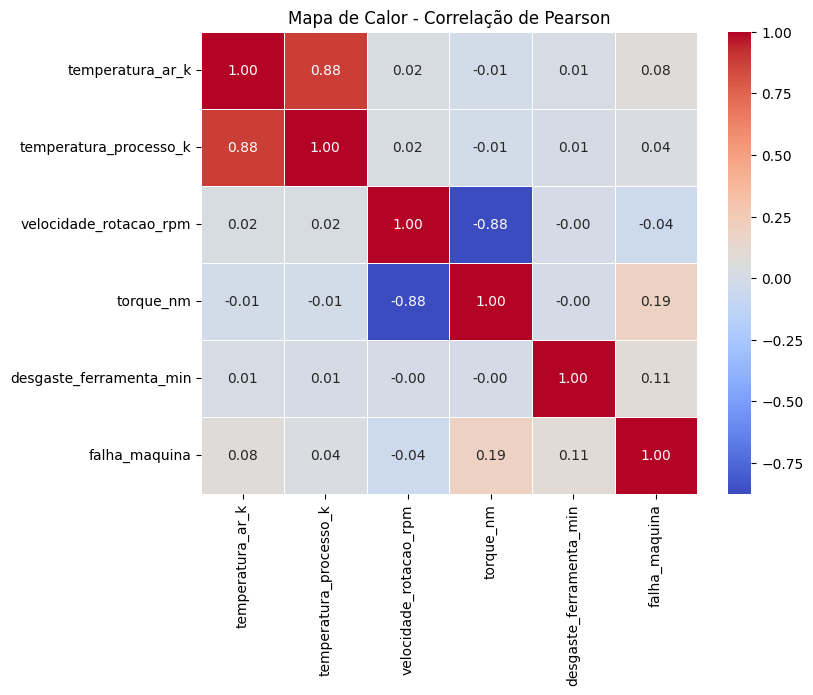

In [26]:
from src.phase01_eda import plotar_correlacao

plotar_correlacao(df)

COMENTÁRIOS DA ANÁLISE EXPLORATóRIA

A análise exploratória demonstra que o conjunto de dados apresenta comportamento consistente com processos industriais. A matriz de dispersão evidencia uma forte correlação linear positiva entre a temperatura do ar (temperatura_ar_k) e a temperatura do processo (temperatura_processo_k), resultado confirmado pelo coeficiente de correlação de Pearson de 0,88, indicando que ambas variáveis compartilham grande parte de sua informação. Da mesma forma, observa-se uma forte correlação negativa entre a velocidade de rotação (velocidade_rotacao_rpm) e o torque (torque_nm), com coeficiente de -0,88, evidenciando que, à medida que a rotação aumenta, o torque tende a diminuir.

As demais combinações de variáveis apresentam coeficientes de correlação próximos de zero, indicando baixa dependência linear. Em relação à variável alvo (falha_maquina), as correlações também são reduzidas, sendo a maior observada com o torque (0,19), seguida pelo desgaste da ferramenta (0,11) e pela temperatura do ar (0,08). Esses resultados sugerem que a ocorrência de falhas não depende de uma única variável.

Os histogramas indicam que as temperaturas e o torque apresentam distribuição aproximadamente normal, enquanto a velocidade de rotação possui distribuição assimétrica e o desgaste da ferramenta apresenta distribuição relativamente uniforme, refletindo diferentes estágios de uso dos equipamentos. Também não são observados outliers relevantes que comprometam a qualidade dos dados.

Por fim, a análise do balanceamento da variável alvo evidencia um forte desbalanceamento entre as classes: 96,6% dos registros correspondem à condição "Sem Falha", enquanto apenas 3,4% representam "Com Falha".

Fase 2: Limpeza e Tratamento de Dados (Data Prep)

Identificação e remoção de linhas duplicadas.

In [27]:
from src.phase02_preprocessing import identificar_duplicatas

identificar_duplicatas(df)

=== Análise de Duplicatas ===
Total de linhas duplicadas: 0
Percentual de duplicatas: 0.00%


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf


Caso haja dados duplicados a próxima função vai eliminá-los

In [28]:
from src.phase02_preprocessing import remover_duplicatas

remover_duplicatas(df)

=== Análise de Duplicatas ===
Total de linhas duplicadas: 0
Percentual de duplicatas: 0.00%
Nenhuma duplicata encontrada. Dataset mantido.


,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604.0,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632.0,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645.0,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408.0,48.5,25,0,0,0,0,0,0


Análise da existência de dados ausentes

In [29]:
from src.phase02_preprocessing import identificar_dados_ausentes

dados_ausentes = identificar_dados_ausentes(df)

=== Análise de Dados Ausentes ===
                        quantidade_ausentes  percentual_ausentes
temperatura_ar_k                        500                  5.0
temperatura_processo_k                  500                  5.0
velocidade_rotacao_rpm                  500                  5.0
torque_nm                               500                  5.0


Distribuição estatística para analisar a melhor forma de substituir os dados ausentes

In [30]:
from src.phase02_preprocessing import checar_distribuicao

display(checar_distribuicao(df))

=== Distribuição das Variáveis Numéricas ===


,media,mediana,desvio_padrao,minimo,percentil_25,percentil_50,percentil_75,maximo,assimetria
udi,5000.50,5000.5,2886.90,1.0,2500.75,5000.5,7500.25,10000.0,0.00
temperatura_ar_k,300.00,300.1,2.00,295.3,298.30,300.1,301.50,304.5,0.11
temperatura_processo_k,310.00,310.1,1.49,305.7,308.80,310.1,311.10,313.8,0.02
velocidade_rotacao_rpm,1539.25,1504.0,180.27,1168.0,1423.00,1504.0,1613.00,2886.0,1.99
torque_nm,39.97,40.1,10.00,3.8,33.10,40.1,46.70,76.6,-0.01
desgaste_ferramenta_min,107.95,108.0,63.65,0.0,53.00,108.0,162.00,253.0,0.03
falha_maquina,0.03,0.0,0.18,0.0,0.00,0.0,0.00,1.0,5.15
falha_twf,0.00,0.0,0.07,0.0,0.00,0.0,0.00,1.0,14.64
falha_hdf,0.01,0.0,0.11,0.0,0.00,0.0,0.00,1.0,9.16
falha_pwf,0.01,0.0,0.10,0.0,0.00,0.0,0.00,1.0,10.11


Regras definidas para a imputação usando média ou mediana
- Quantidade de dados ausentes (percentual_ausente)) tem que ser menor que 10%
- Assimetria entre -1 e 1 será usado a média
- demais casos será usado mediana 

In [31]:
from src.phase02_preprocessing import definir_metodo_imputacao

metodos = definir_metodo_imputacao(df)
metodos_imputacao = definir_metodo_imputacao(df)

display(metodos)

=== Distribuição das Variáveis Numéricas ===
=== Análise de Dados Ausentes ===
                        quantidade_ausentes  percentual_ausentes
temperatura_ar_k                        500                  5.0
temperatura_processo_k                  500                  5.0
velocidade_rotacao_rpm                  500                  5.0
torque_nm                               500                  5.0
=== Distribuição das Variáveis Numéricas ===
=== Análise de Dados Ausentes ===
                        quantidade_ausentes  percentual_ausentes
temperatura_ar_k                        500                  5.0
temperatura_processo_k                  500                  5.0
velocidade_rotacao_rpm                  500                  5.0
torque_nm                               500                  5.0


,variavel,percentual_ausentes,assimetria,metodo_imputacao
0,temperatura_ar_k,5.0,0.11,Média
1,temperatura_processo_k,5.0,0.02,Média
2,velocidade_rotacao_rpm,5.0,1.99,Mediana
3,torque_nm,5.0,-0.01,Média


Com base nas sugestões acima, agora é possível aplicar no data frame sem itens duplicados a substituição dos dados ausentes por média ou mediana

In [32]:
from src.phase02_preprocessing import substituir_dados_ausentes

df_processado = substituir_dados_ausentes(df, metodos_imputacao)

=== Imputação de Dados Ausentes ===
temperatura_ar_k: 500 valor(es) substituído(s) pela média (300.00)
temperatura_processo_k: 500 valor(es) substituído(s) pela média (310.00)
velocidade_rotacao_rpm: 500 valor(es) substituído(s) pela mediana (1504.00)
torque_nm: 500 valor(es) substituído(s) pela média (39.97)

Imputação concluída.


Utilizando novamente a função identificar_dados_ausentes para identificar se não há mais dados ausentes.

In [33]:
display(identificar_dados_ausentes(df_processado))


Nenhum dado ausente encontrado.


,quantidade_ausentes,percentual_ausentes


A proxima seção será postado Box plots para ver como estão os dados preditórios

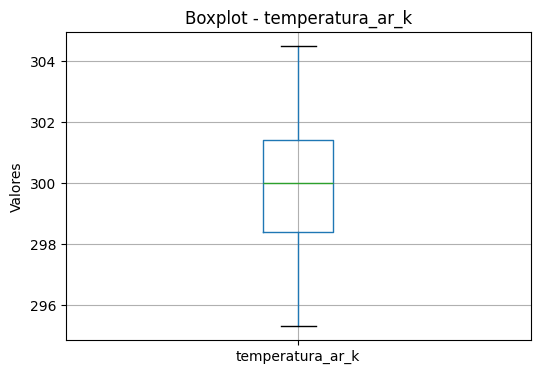

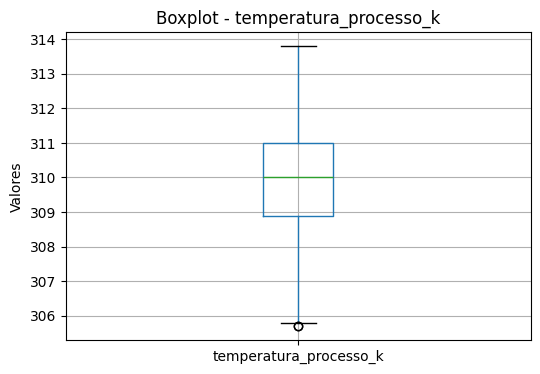

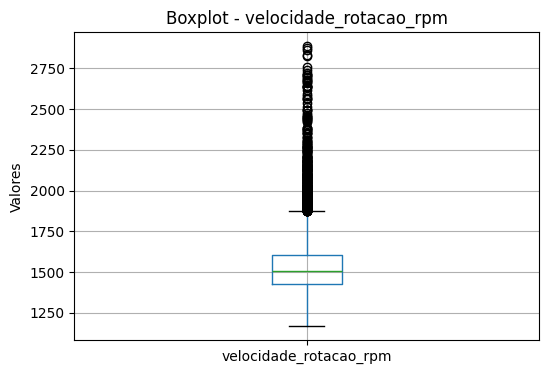

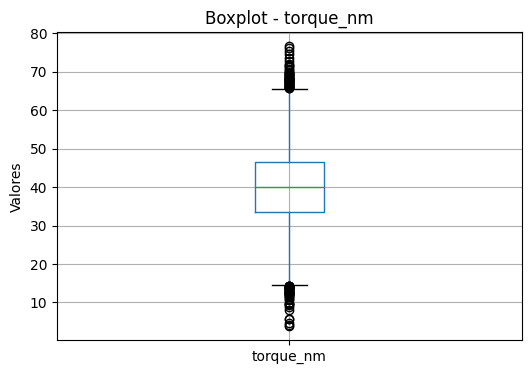

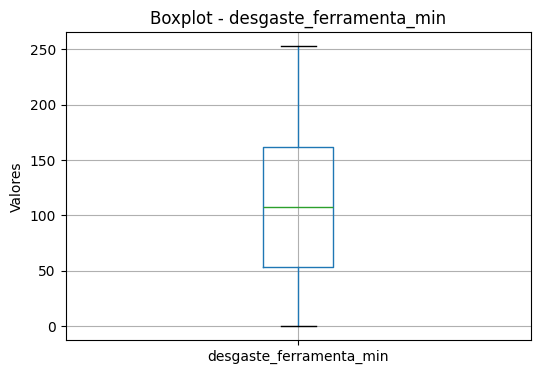

In [34]:
from src.phase02_preprocessing import plotar_boxplots

plotar_boxplots(df_processado)

Analisando o gráfico acima, podemos ver que os boxplots indicam que as variáveis temperatura_ar_k, temperatura_processo_k e desgaste_ferramente_min apresentam poucos ou nenhum valor considerado outlier. A variáveis torque_nm uma pequena quantidade de outliers. Já velocidade_rotacao_rpm apresenta uma concentração significativamente maior de valores classificados como outliers, principalmente acima do limite superior do boxplot.

Por ultimo, converter os dados que representam informações com 0 e 1 para boolenos

In [35]:
from src.phase02_preprocessing import converter_booleanos


df = converter_booleanos(df_processado)

=== Conversão de Variáveis Booleanas ===
falha_maquina: convertido para bool
falha_twf: convertido para bool
falha_hdf: convertido para bool
falha_pwf: convertido para bool
falha_osf: convertido para bool
falha_rnf: convertido para bool

Conversão concluída.


Para finalizar esta etapa, há uma coluna chamada tipo que é do tipo categórica que pode ser util no futuro. Então vamos usar a técnica One-Hot Enconding nesta variável para transformar cada opção (H, M e L) em variáveis separadas e mais utéis para futuras análises de ML.

In [36]:
from src.phase02_preprocessing import aplicar_one_hot_encoding

df = aplicar_one_hot_encoding(df, ["tipo"])

=== One-Hot Encoding ===
Colunas codificadas: tipo


FASE 3 - FEATURE ENGINEERING 

O primeiro ajuste será criar uma coluna potencia que é o produto de velocidade_rotacao_rpm e torque_nm. Complementarmente, vai ser criada uma coluna sobre variação de temperatura.

In [37]:
from src.phase03_featengineering import (
    criar_feature_potencia,
    criar_delta_temp_k,
)

df = criar_feature_potencia(df)
df = criar_delta_temp_k(df)

display(df)

,udi,id_produto,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf,tipo_H,tipo_L,tipo_M,potencia,delta_temp
0,1,M14860,298.100000,308.600000,1551.0,42.800000,0,False,False,False,False,False,False,False,False,True,66382.800000,10.500000
1,2,L47181,298.200000,308.700000,1408.0,46.300000,3,False,False,False,False,False,False,False,True,False,65190.400000,10.500000
2,3,L47182,298.100000,308.500000,1498.0,49.400000,5,False,False,False,False,False,False,False,True,False,74001.200000,10.400000
3,4,L47183,300.002158,310.000895,1504.0,39.974168,7,False,False,False,False,False,False,False,True,False,60121.149305,9.998737
4,5,L47184,298.200000,308.700000,1408.0,40.000000,9,False,False,False,False,False,False,False,True,False,56320.000000,10.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,298.800000,308.400000,1604.0,29.500000,14,False,False,False,False,False,False,False,False,True,47318.000000,9.600000
9996,9997,H39410,298.900000,308.400000,1632.0,31.800000,17,False,False,False,False,False,False,True,False,False,51897.600000,9.500000
9997,9998,M24857,299.000000,308.600000,1645.0,33.400000,22,False,False,False,False,False,False,False,False,True,54943.000000,9.600000
9998,9999,H39412,299.000000,308.700000,1408.0,48.500000,25,False,False,False,False,False,False,True,False,False,68288.000000,9.700000


A nova feature potencia representa uma aproximação da potência operacional enquanto a feature delta_temp_k representa a variação entre a temperatura de operação e temperatura ambiente. A hipotese é que ela pode demonstrar que onde há uma maior variação tem mais chances de falha.

FASE 4: Divisão e Balanceamento dos Dados

Nossa primeira ação vai ser separar as variáveis preditoras (X) da variável alvo (y). A premissa usada foi:

VARIAVEL_ALVO = "falha_maquina"

COLUNAS_DESCARTADAS
    "udi",
    "id_produto",
    "falha_twf",
    "falha_hdf",
    "falha_pwf",
    "falha_osf",
    "falha_rnf",

PREDITORAS
    "temperatura_ar_k",
    "temperatura_processo_k",
    "velocidade_rotacao_rpm",
    "torque_nm",
    "desgaste_ferramenta_min",



In [39]:
from src.phase04_balancing import separar_features_target

x, y = separar_features_target(df)

display(x)
display(y)

SyntaxError: '[' was never closed (phase04_balancing.py, line 8)

Criando a base de treinamento e a bas de testes

In [ ]:
from src.phase04_balancing import separar_train_test

x_train, x_test, y_train, y_test = separar_train_test(x, y)

Aplicação da técnica SMOTE para balancear a classe minoritária apenas no conjunto de treino.

In [ ]:
from src.phase04_balancing import aplicar_smote

x_train, y_train = aplicar_smote(
    x_train,
    y_train
)

display(x_train.head())
display(y_train.head())